# Fase 2 — Ingeniería de Features

**Objetivo:** transformar los 17 sensores multifrecuencia (60/600/6000 lecturas por ciclo, según la magnitud) en una matriz de features lista para entrenar los clasificadores de la Fase 4 — un vector de estadísticos por ciclo (nivel, forma y fase) en lugar de las lecturas crudas.

## Contexto del EDA que condiciona esta fase

Este notebook parte directamente de los hallazgos de `01_eda.ipynb`. Cuatro de ellos no son solo contexto informativo — son restricciones concretas sobre cómo construir las features:

1. **`stable_flag=1` marca 756 ciclos de transición entre regímenes**, no un estado de degradación real. Filtrarlos es correcto, pero cambia sustancialmente el balance de clases de `pump_leakage` (de 55%/22%/22% a ~34%/33%/33%) — un efecto a documentar, no a ignorar, al evaluar el modelo de ese target en la Fase 4.
2. **Los ciclos 617 y 371 tienen una anomalía física confirmada en PS3**: su pico de presión aparece en el segundo ~49 del ciclo en vez de en el segundo ~9-10 del resto de su grupo — un desplazamiento un orden de magnitud mayor que cualquier retraso de válvula documentado. Se excluyen del entrenamiento antes de construir cualquier feature de posición de pico.
3. **`cooler_condition` domina la varianza de casi todos los sensores**, no solo de los que se le atribuyeron por hipótesis física. `PS3` tiene η²=0.53 con `cooler_condition` frente a solo η²=0.032 con `valve_condition` (su hipótesis "propia"); `VS1` tiene η²=0.79 con `cooler_condition` frente a η²=0.026 con `pump_leakage`. No es confusión estadística en sentido estricto — los targets están diseñados para ser independientes (Sección 2 del EDA) — pero sí significa que buena parte de la varianza de nivel de esos sensores no es atribuible al componente que en principio deberían diagnosticar. Vigilar esto al interpretar la importancia de features en la Fase 4.
4. **Cualquier cálculo de η² — o de cualquier otra métrica usada para decidir qué features construir o seleccionar — debe hacerse solo sobre el conjunto de entrenamiento** una vez exista el split train/test. Los valores de η² del EDA son guía exploratoria para priorizar qué construir aquí, no un criterio de selección final.

El patrón **Decisión → Código → Interpretación** del EDA se mantiene igual en este notebook: cada bloque de código va precedido de por qué se hace y qué alternativas se descartaron, y seguido de la lectura de los resultados reales obtenidos al ejecutarlo.


In [1]:
import sys  # necesario para modificar sys.path y poder importar módulos de src/
from pathlib import Path  # manejo de rutas multiplataforma

import numpy as np  # operaciones numéricas vectorizadas
import pandas as pd  # DataFrames para targets y tablas resumen
from scipy.ndimage import uniform_filter1d  # suavizado de la señal de PS3 (ventana móvil) para features de posición de pico
from scipy.stats import spearmanr  # correlación de rangos para la feature de fase (Sección 2)
from sklearn.model_selection import train_test_split  # split estratificado train/test

sys.path.append(str(Path.cwd().parent / "src"))  # añade hydraulic_maintenance/src/ al path de import
from data_loader import SENSOR_FREQUENCIES_HZ, load_hydraulic_dataset  # mismas funciones/constantes que en el EDA

PROCESSED_DIR = Path.cwd().parent / "data" / "processed"  # destino de la matriz de features de esta fase
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)  # la crea si no existe; no falla si ya existe

RANDOM_STATE = 42  # semilla fija para reproducibilidad del split y de cualquier paso aleatorio posterior

OUTLIER_CYCLES = [617, 371]  # ciclos con anomalía física confirmada en PS3 (Sección 3 del EDA) — se excluyen del entrenamiento
COMPONENT_TARGETS = ["cooler_condition", "valve_condition", "pump_leakage", "accumulator_pressure"]  # los 4 targets de componente, sin stable_flag

sensors, y = load_hydraulic_dataset()  # carga el dataset completo (17 sensores + 5 columnas de profile.txt)


## 0. Carga y preprocesamiento

**Decisión — por qué este orden exacto de los 3 pasos y no otro:**

**1º, los outliers físicos (617 y 371):** se excluyen antes que ningún otro paso, incluido el split. Si entrasen en el split, podrían caer en el conjunto de test — y evaluar la futura feature `PS3_peak_position_s` sobre un ciclo cuyo pico está desplazado ~40 segundos por una anomalía de sensor, no por degradación de válvula, contaminaría esa evaluación con un caso que no representa el fenómeno que se quiere medir. Excluirlos primero, antes de calcular nada más, elimina ese riesgo de raíz.

**2º, el filtrado de `stable_flag=1`:** se hace antes del split, y es una excepción deliberada a la regla general de "todo cálculo se hace después de separar train/test" (nota de leakage, Sección 5 del EDA) — porque `stable_flag` no es una métrica calculada a partir de los sensores que pudiera filtrarse desde el test, sino una variable de control del propio experimento, ya fijada en `profile.txt` igual que los 4 targets, no derivada de ninguna lectura de sensor. Filtrarla antes del split no usa información del test para decidir nada, así que no introduce fuga. Lo que sí introduciría un problema es filtrarla *después* del split: `stable_flag` está muy concentrado en ciertas clases (100% de los ciclos inestables tienen `valve_condition=100`; 60% de los ciclos con `pump_leakage=0` son inestables — Sección 2 del EDA), así que dividir primero y filtrar cada mitad por separado generaría proporciones de clase distintas entre train y test — el filtrado tiene que aplicarse a la misma población antes de dividirla.

**3º, el split 80/20:** se hace al final, estratificado por la combinación completa de los 4 targets como una única clave, para que las 144 combinaciones del diseño factorial completo (Sección 2 del EDA) queden representadas en ambos conjuntos — estratificar por un solo target a la vez podría dejar alguna combinación específica de los otros 3 solo en train o solo en test. La clave se construye explícitamente como texto concatenado (`"3_100_0_130"`, etc.) en vez de pasar las 4 columnas directamente: el resultado es idéntico (`scikit-learn` sí admite un array 2D como `stratify`, se comprobó), pero la clave como columna de texto es auditable con `value_counts()` antes de dividir — se puede ver de un vistazo cuántos ciclos hay por combinación y confirmar que ninguna tiene menos de 2 (mínimo necesario para que el split estratificado no falle).


In [2]:
# ── Paso 1: excluir los 2 ciclos outlier de sensores y targets simultáneamente ──
sensors_clean = {name: np.delete(arr, OUTLIER_CYCLES, axis=0) for name, arr in sensors.items()}  # elimina filas 617 y 371 de cada matriz de sensor
y_clean = y.drop(index=OUTLIER_CYCLES).reset_index(drop=True)  # elimina las mismas filas de targets y renumera el índice 0..N-1
print(f"Tras Paso 1 (excluir outliers 617, 371): {len(y_clean)} ciclos")

# ── Paso 2: filtrar los ciclos con stable_flag=1 ──
stable_mask = (y_clean["stable_flag"] == 0).values  # True para ciclos estables, False para los de transición
sensors_stable = {name: arr[stable_mask] for name, arr in sensors_clean.items()}  # aplica la misma máscara a cada sensor
y_stable = y_clean.loc[stable_mask].reset_index(drop=True)  # y a los targets, renumerando el índice
print(f"Tras Paso 2 (excluir stable_flag=1): {len(y_stable)} ciclos")

# Tabla de balance antes/después del filtrado de stable_flag, para hacer visible el cambio de distribución
print("\nDistribución (%) de cada target, antes vs. después del filtrado de stable_flag:")
for target in COMPONENT_TARGETS:
    before_pct = (y_clean[target].value_counts(normalize=True).sort_index() * 100).round(1)  # % por clase antes de filtrar
    after_pct = (y_stable[target].value_counts(normalize=True).sort_index() * 100).round(1)  # % por clase después de filtrar
    comparison = pd.DataFrame({"antes (%)": before_pct, "después (%)": after_pct})
    print(f"\n{target}:")
    print(comparison)

# ── Paso 3: split 80/20 estratificado por la combinación completa de los 4 targets ──
strat_key = y_stable[COMPONENT_TARGETS].astype(str).agg("_".join, axis=1)  # una clave de texto por ciclo, p.ej. "3_100_0_130"
print(f"\nCombinaciones distintas de (cooler, valve, pump, accumulator) presentes: {strat_key.nunique()}")
print(f"Réplicas por combinación: min={strat_key.value_counts().min()}, max={strat_key.value_counts().max()}")

idx_train, idx_test = train_test_split(
    np.arange(len(y_stable)), test_size=0.2, stratify=strat_key, random_state=RANDOM_STATE
)  # se divide un array de índices, no los datos directamente, para poder aplicar la misma partición a sensores y targets

sensors_train = {name: arr[idx_train] for name, arr in sensors_stable.items()}
sensors_test = {name: arr[idx_test] for name, arr in sensors_stable.items()}
y_train = y_stable.iloc[idx_train].reset_index(drop=True)
y_test = y_stable.iloc[idx_test].reset_index(drop=True)

print(f"\nTrain: {len(y_train)} ciclos ({len(y_train) / len(y_stable) * 100:.1f}%)")
print(f"Test:  {len(y_test)} ciclos ({len(y_test) / len(y_stable) * 100:.1f}%)")

combos_train = set(y_train[COMPONENT_TARGETS].astype(str).agg("_".join, axis=1))  # combinaciones únicas presentes en train
combos_test = set(y_test[COMPONENT_TARGETS].astype(str).agg("_".join, axis=1))  # combinaciones únicas presentes en test
print(f"Combinaciones representadas en train: {len(combos_train)}/{strat_key.nunique()}")
print(f"Combinaciones representadas en test:  {len(combos_test)}/{strat_key.nunique()}")

# ── Verificación de NaN tras todo el preprocesamiento ──
for split_name, sensors_split, y_split in [("train", sensors_train, y_train), ("test", sensors_test, y_test)]:
    for sensor_name, arr in sensors_split.items():
        assert not np.isnan(arr).any(), f"NaN encontrado en sensor '{sensor_name}' del split '{split_name}' tras el preprocesamiento"
    assert not y_split.isnull().values.any(), f"NaN encontrado en targets del split '{split_name}' tras el preprocesamiento"
print("\nVerificación de NaN: OK — ningún valor nulo en sensores ni targets tras el preprocesamiento.")


Tras Paso 1 (excluir outliers 617, 371): 2203 ciclos
Tras Paso 2 (excluir stable_flag=1): 1447 ciclos

Distribución (%) de cada target, antes vs. después del filtrado de stable_flag:

cooler_condition:
                  antes (%)  después (%)
cooler_condition                        
3                      33.1         33.0
20                     33.2         33.2
100                    33.6         33.8

valve_condition:
                 antes (%)  después (%)
valve_condition                        
73                    16.3         24.8
80                    16.3         24.9
90                    16.3         24.8
100                   51.1         25.5

pump_leakage:
              antes (%)  después (%)
pump_leakage                        
0                  55.4         33.8
1                  22.3         33.2
2                  22.2         33.0

accumulator_pressure:
                      antes (%)  después (%)
accumulator_pressure                        
90                    


Train: 1157 ciclos (80.0%)
Test:  290 ciclos (20.0%)
Combinaciones representadas en train: 144/144
Combinaciones representadas en test:  144/144

Verificación de NaN: OK — ningún valor nulo en sensores ni targets tras el preprocesamiento.


**Interpretación:**

**Recuento por paso:** 2205 ciclos originales → 2203 tras excluir los 2 outliers (617, 371) → 1447 tras excluir los 756 ciclos con `stable_flag=1`. El 34.4% de los ciclos se pierde en el segundo filtro, tal como anticipaba el EDA.

**El efecto de balanceo de `stable_flag` es más amplio de lo que documentó el EDA — no es solo `pump_leakage`:**

- `cooler_condition` apenas cambia (33.1/33.2/33.6% → 33.0/33.2/33.8%) — consistente con que `stable_flag` es ~independiente de este target (Sección 2 del EDA).
- `pump_leakage` pasa de 55.4/22.3/22.2% a 33.8/33.2/33.0% — coincide con la predicción del EDA (~34/33/33%).
- `valve_condition` pasa de 51.1/16.3/16.3/16.3% a 25.5/24.8/24.9/24.8% — el cambio más dramático de los cuatro: de una clase mayoritaria con más de la mitad de los ciclos a un reparto casi perfectamente uniforme entre las 4 clases. El EDA no cuantificó este caso explícitamente, solo advirtió que `stable_flag=1` está concentrado al 100% en `valve_condition=100`.
- `accumulator_pressure` pasa de 36.6/18.1/18.1/27.2% a 25.4/24.9/24.8/24.9% — también se acerca mucho a un reparto uniforme, otro efecto no cuantificado antes.

**Consecuencia práctica para la Fase 4:** con este preprocesamiento, los 4 targets quedan moderada a muy bien balanceados (el más desviado, `pump_leakage`, no pasa de ~34% en su clase mayor) — `class_weight='balanced'` debería bastar para los 4 sin necesidad de SMOTE, confirmando y reforzando lo que el EDA solo había verificado para `pump_leakage`.

**Split y verificación:** el split 80/20 estratificado deja 1157 ciclos en train y 290 en test (80.0%/20.0% exactos), con las 144 combinaciones del diseño factorial representadas en ambos conjuntos (144/144). La verificación final de NaN no encontró ningún valor nulo en sensores ni targets tras los 3 pasos de preprocesamiento.


## 1. Features de nivel: estadísticos globales del ciclo

**Decisión:** para los sensores cuyo mecanismo de respuesta a la degradación es un cambio de *nivel* — el EDA demostró η² altos con la media de ciclo para `CE`/`TS3` frente a `cooler_condition` (0.996/0.936) y `EPS1`/`PS2` frente a `pump_leakage` (0.189/0.108) — el estadístico relevante es directamente la media del ciclo completo. Estos son los casos donde una feature simple ya captura la mayor parte de la señal.

`accumulator_pressure` es distinto: es el target más difícil, con η²=0.048 con su mejor sensor de nivel (`PS5`). La hipótesis física (Sección 3 del EDA) es que el acumulador no se manifiesta en la presión *media*, sino en cuánto amortigua las oscilaciones de presión dentro del ciclo — su función es absorber picos, y un acumulador con precarga de gas baja amortigua peor, por lo que la presión debería oscilar más dentro de un mismo ciclo cuando el acumulador está degradado. Eso requiere una métrica distinta de la ya calculada en el EDA: la **desviación estándar intra-ciclo** (`arr[i].std()`, sobre las N lecturas de un único ciclo) es estadísticamente diferente de la std *entre* ciclos que se usó en la Sección 3 del EDA (`arr[mask].std(axis=0)`, que fija el instante temporal y mide cuánto varían distintos ciclos entre sí en ese mismo instante). Ninguna de las dos es "la std" en abstracto — miden fuentes de variación distintas, y aquí interesa la primera.

También se calculan las medias de la primera y segunda mitad de cada ciclo, para detectar posibles asimetrías temporales que ni la media global ni la std intra-ciclo distinguirían por sí solas (una señal que sube y luego baja a la misma media que una que se mantiene plana tendría la misma media global, pero mitades distintas).

**Sobre la separación train/test:** toda decisión sobre *qué* features construir y *por qué* se razona únicamente a partir de `sensors_train` — el razonamiento de esta celda no usa ningún dato de test. El conjunto de test se toca solo mecánicamente en el código siguiente, aplicando las mismas fórmulas ya decididas aquí sin derivar nada nuevo a partir de él. Esto es disciplina de buena práctica más que una necesidad estricta en este caso concreto: cada feature de esta sección es una función de las lecturas de un único ciclo (no hay ningún parámetro ajustado sobre el conjunto de entrenamiento, como sí lo habrá más adelante si se normalizan features), así que no hay fuga posible aquí — pero mantener la disciplina ahora evita tener que introducirla de golpe cuando sí sea necesaria.


In [3]:
def compute_level_features(sensors_dict):
    """Para cada sensor y cada ciclo, calcula media, std intra-ciclo y medias de cada mitad.
    Vectorizado sobre el eje de lecturas (axis=1): arr.mean(axis=1)[i] == arr[i].mean(), pero
    para las N filas (ciclos) a la vez en vez de con un bucle explícito en Python."""
    features = {}
    for name, arr in sensors_dict.items():  # arr tiene shape (n_ciclos, N_lecturas), N depende de la frecuencia del sensor
        half = arr.shape[1] // 2  # límite de la mitad del ciclo: 3000 lecturas (100Hz), 300 (10Hz) o 30 (1Hz)
        features[f"{name}_mean"] = arr.mean(axis=1)  # media del ciclo completo, una por ciclo
        features[f"{name}_std"] = arr.std(axis=1)  # std INTRA-ciclo: dispersión de las lecturas dentro de cada ciclo individual
        features[f"{name}_mean_first_half"] = arr[:, :half].mean(axis=1)  # media de la primera mitad del ciclo
        features[f"{name}_mean_second_half"] = arr[:, half:].mean(axis=1)  # media de la segunda mitad del ciclo
    return pd.DataFrame(features)  # una fila por ciclo, una columna por feature


features_train = compute_level_features(sensors_train)  # todas las decisiones de diseño de features se basan solo en esto
print(f"features_train: {features_train.shape[0]} ciclos x {features_train.shape[1]} features")
print("\nColumnas de CE (primeros 3 ciclos):")
print(features_train.filter(like="CE_").head(3))
print("\nColumnas de PS3 (primeros 3 ciclos):")
print(features_train.filter(like="PS3_").head(3))

# Se aplica exactamente la misma función (misma lógica, sin recalcular ni derivar nada nuevo) sobre test
features_test = compute_level_features(sensors_test)
print(f"\nfeatures_test: {features_test.shape[0]} ciclos x {features_test.shape[1]} features")


features_train: 1157 ciclos x 68 features

Columnas de CE (primeros 3 ciclos):
     CE_mean    CE_std  CE_mean_first_half  CE_mean_second_half
0  27.444867  0.345259           27.725167            27.164567
1  20.481067  0.341850           20.690667            20.271467
2  46.981400  0.378459           47.282833            46.679967

Columnas de PS3 (primeros 3 ciclos):
   PS3_mean   PS3_std  PS3_mean_first_half  PS3_mean_second_half
0  1.753059  0.880450             1.459109              2.047009
1  1.749061  0.876769             1.454648              2.043473
2  1.945208  0.917131             1.607660              2.282756

features_test: 290 ciclos x 68 features


In [4]:
def eta_squared(values, groups):
    """Calcula eta^2 = SS_entre_grupos / SS_total (idéntica a la función usada en el EDA)."""
    df = pd.DataFrame({"v": values, "g": groups})
    grand_mean = df["v"].mean()
    ss_total = ((df["v"] - grand_mean) ** 2).sum()
    ss_between = df.groupby("g")["v"].apply(lambda x: len(x) * (x.mean() - grand_mean) ** 2).sum()
    return ss_between / ss_total


# Referencia: los η² que el EDA calculó sobre el dataset completo SIN filtrar (2205 ciclos, incluyendo
# los inestables). No son directamente comparables sin más al recalculo aquí: ver el diagnóstico más abajo.
eda_reference = {
    ("CE_mean", "cooler_condition"): 0.996,
    ("TS3_mean", "cooler_condition"): 0.936,
    ("EPS1_mean", "pump_leakage"): 0.189,
    ("PS2_mean", "pump_leakage"): 0.108,
    ("PS5_mean", "accumulator_pressure"): 0.048,
    ("PS3_mean", "valve_condition"): 0.032,
}

validation_rows = []
for (feature, target), eda_ref in eda_reference.items():  # recalcula cada par sobre el training set
    eta2_train = eta_squared(features_train[feature], y_train[target])
    validation_rows.append(
        {"feature": feature, "target": target, "eta2_EDA": eda_ref, "eta2_train": round(eta2_train, 4), "diff": round(abs(eta2_train - eda_ref), 4)}
    )
validation_table = pd.DataFrame(validation_rows)
print("Comparación η² EDA (dataset completo, 2205 ciclos) vs. training (tras preprocesamiento, 1157 ciclos):")
print(validation_table.to_string(index=False))

# Diagnóstico automático para cualquier diff > 0.01: en vez de asumir una causa, se comprueba.
# Se calcula el mismo η² sobre TODO el conjunto ya filtrado pero SIN dividir train/test (sensors_stable,
# 1447 ciclos) — si ese valor ya coincide con el de train, la diferencia respecto al EDA es por el
# filtrado (Sección 0), no por el split. Si en cambio el valor sobre sensors_stable se pareciera más al
# EDA que al de train, sí apuntaría a un problema real de representatividad del split.
features_stable = compute_level_features(sensors_stable)
print("\nDiagnóstico de las diferencias > 0.01 respecto al EDA:")
any_warning = False
for _, row in validation_table.iterrows():
    if row["diff"] > 0.01:
        any_warning = True
        eta2_stable = eta_squared(features_stable[row["feature"]], y_stable[row["target"]])
        diff_por_split = abs(row["eta2_train"] - eta2_stable)
        causa = "filtrado de stable_flag/outliers (Sección 0), no el split" if diff_por_split < 0.01 else "el split no preservó la distribución — revisar"
        print(
            f"  AVISO: {row['feature']} vs {row['target']}: diff={row['diff']} vs. EDA -> "
            f"η² sobre el conjunto filtrado sin dividir={eta2_stable:.4f} (diff atribuible al split={diff_por_split:.4f}) "
            f"-> causa: {causa}"
        )
if not any_warning:
    print("  Ninguna diferencia supera 0.01 — no hace falta diagnóstico adicional.")

# η² de PS5_std (intra-ciclo) con accumulator_pressure — primer número real para esta hipótesis, no existe en el EDA
eta2_ps5_std = eta_squared(features_train["PS5_std"], y_train["accumulator_pressure"])
eta2_ps5_mean = eta_squared(features_train["PS5_mean"], y_train["accumulator_pressure"])
print(f"\nPS5_std vs accumulator_pressure: η²={eta2_ps5_std:.4f}  (comparar con PS5_mean: η²={eta2_ps5_mean:.4f})")


Comparación η² EDA (dataset completo, 2205 ciclos) vs. training (tras preprocesamiento, 1157 ciclos):
  feature               target  eta2_EDA  eta2_train   diff
  CE_mean     cooler_condition     0.996      0.9983 0.0023
 TS3_mean     cooler_condition     0.936      0.9893 0.0533
EPS1_mean         pump_leakage     0.189      0.1526 0.0364
 PS2_mean         pump_leakage     0.108      0.0640 0.0440
 PS5_mean accumulator_pressure     0.048      0.0010 0.0470
 PS3_mean      valve_condition     0.032      0.0005 0.0315



Diagnóstico de las diferencias > 0.01 respecto al EDA:
  AVISO: TS3_mean vs cooler_condition: diff=0.0533 vs. EDA -> η² sobre el conjunto filtrado sin dividir=0.9893 (diff atribuible al split=0.0000) -> causa: filtrado de stable_flag/outliers (Sección 0), no el split
  AVISO: EPS1_mean vs pump_leakage: diff=0.0364 vs. EDA -> η² sobre el conjunto filtrado sin dividir=0.1524 (diff atribuible al split=0.0002) -> causa: filtrado de stable_flag/outliers (Sección 0), no el split
  AVISO: PS2_mean vs pump_leakage: diff=0.044 vs. EDA -> η² sobre el conjunto filtrado sin dividir=0.0641 (diff atribuible al split=0.0001) -> causa: filtrado de stable_flag/outliers (Sección 0), no el split
  AVISO: PS5_mean vs accumulator_pressure: diff=0.047 vs. EDA -> η² sobre el conjunto filtrado sin dividir=0.0010 (diff atribuible al split=0.0000) -> causa: filtrado de stable_flag/outliers (Sección 0), no el split
  AVISO: PS3_mean vs valve_condition: diff=0.0315 vs. EDA -> η² sobre el conjunto filtrado sin di

**Interpretación:**

**Forma de la matriz de features:** `features_train` tiene 1157 ciclos × 68 columnas (17 sensores × 4 estadísticos), `features_test` tiene 290 × 68 — consistente con el tamaño del split de la Sección 0.

**La comparación η² EDA vs. training confirma que la diferencia es por el filtrado, no por el split — con un matiz importante que no era obvio de antemano.** Solo `CE_mean` se mantiene dentro de 0.01 del valor del EDA (0.996 → 0.998); los otros 5 pares difieren más de 0.03. El diagnóstico automático lo aclara sin ambigüedad: en los 5 casos, la diferencia atribuible al split es ≤0.0002 — el split reproduce casi perfectamente la distribución del conjunto filtrado. Toda la diferencia viene de comparar contra el EDA original (2205 ciclos, sin filtrar), no de ningún problema con `train_test_split`.

Dentro de eso hay dos patrones opuestos:
- **`cooler_condition` sube:** `CE_mean` (0.996→0.998) y `TS3_mean` (0.936→0.989) aumentan tras filtrar — eliminar los ciclos de transición limpia ruido y hace la separación entre clases de `cooler_condition` aún más nítida.
- **`pump_leakage`, `valve_condition` y `accumulator_pressure` bajan, y en dos casos casi desaparecen:** `PS5_mean`/`accumulator_pressure` cae de 0.048 a 0.001, y `PS3_mean`/`valve_condition` de 0.032 a 0.0005 — señales que ya eran débiles en el EDA quedan prácticamente en cero sobre la población de entrenamiento real. Esto no es un error del pipeline: es coherente con lo que documentó la Sección 0 — los 756 ciclos filtrados estaban muy concentrados en `valve_condition=100` y `pump_leakage=0`, así que quitarlos no solo cambia el balance de clases, también quita precisamente los ciclos "extra" que aportaban una diferencia de nivel entre grupos hoy sabemos que espuria. **Conclusión práctica:** para `valve_condition` y `accumulator_pressure`, las features de nivel no solo son débiles como ya se sabía — son casi inútiles sobre los datos reales de entrenamiento. La necesidad de features de fase/forma (posición de pico de PS3 para la válvula) es aún más urgente de lo que sugería el EDA.

**`PS5_std` (intra-ciclo) confirma la hipótesis del acumulador, con una mejora real pero modesta:** η²=0.0575 frente a η²=0.0010 de `PS5_mean` sobre la misma población de entrenamiento — una mejora de ~57 veces, y también supera el η²=0.048 de referencia del EDA (calculado con la media, sobre el dataset sin filtrar). La std intra-ciclo es, con los datos actuales, una feature de nivel mejor que la media para `accumulator_pressure` — confirma la hipótesis física de la Decisión. Dicho esto, 0.0575 sigue siendo un efecto pequeño en términos absolutos (umbral de Cohen para "pequeño" ≈0.01, "mediano" ≈0.06) — el acumulador sigue siendo, con mucha diferencia, el target más difícil de los 4, y esta mejora no lo resuelve por sí sola.


## 2. Feature de fase: posición del pico de PS3

**Decisión:** la posición temporal del pico de `PS3` es la única feature de fase justificada por el EDA. El análisis (Sección 3) mostró que los cuatro grupos de `valve_condition` tienen medianas de pico separadas ~31 lecturas (0.31s) con IQRs internos de solo 2-3 lecturas — una relación señal/ruido ≈10:1, suficiente para que una sola feature capture la mayoría de la varianza ordinal de la válvula.

El pico no puede extraerse con `argmax` directamente sobre la señal cruda porque a 100Hz hay ruido de alta frecuencia: una lectura ruidosa puntual puede desplazar el `argmax` varios cientos de muestras sin reflejar ningún cambio real en el tiempo de apertura de la válvula. Este es exactamente el mecanismo que produjo los outliers 617 y 371 (Sección 3 del EDA): su pico detectado por `argmax` crudo aparecía en el segundo ~49 en vez de ~9-10. La solución es suavizar primero con `uniform_filter1d` y una ventana de 50 muestras (=0.5s a 100Hz) para atenuar el ruido manteniendo la forma general del transitorio, y extraer el `argmax` del array ya suavizado — con esta ventana, variaciones de ±25 muestras de ruido quedan absorbidas.

El suavizado se aplica **ciclo a ciclo, no sobre el array aplanado**: cada ciclo es independiente, y aplanar los 1157 ciclos en un único array 1D introduciría un transitorio espurio en cada frontera entre ciclos (el filtro mezclaría el final de un ciclo con el principio del siguiente). En la práctica esto se implementa con `uniform_filter1d(..., axis=1)`, que filtra cada fila de la matriz `(n_ciclos, 6000)` de forma independiente — matemáticamente idéntico a suavizar cada ciclo por separado en un bucle, pero vectorizado (se comprobó la equivalencia exacta antes de escribir esta celda). El resultado por ciclo es un único escalar: la posición del máximo suavizado de PS3, en segundos (`argmax / 100.0`), al que llamamos `PS3_peak_s`.

Como en la Sección 1, esta feature se diseña y valida (η², correlación) únicamente sobre el conjunto de entrenamiento; después se aplica exactamente el mismo procedimiento — sin recalibrar nada — al conjunto de test, porque es una transformación determinista sin parámetros que ajustar.


In [5]:
def compute_ps3_peak_seconds(ps3_array):
    """Suaviza cada ciclo de PS3 (ventana de 50 muestras = 0.5s a 100Hz) y devuelve la posición
    del máximo suavizado, en segundos. axis=1 filtra cada fila (ciclo) de forma independiente —
    equivalente a suavizar ciclo a ciclo en un bucle, sin aplanar el array."""
    smoothed = uniform_filter1d(ps3_array, size=50, axis=1)  # ventana de 50 muestras, por fila
    return smoothed.argmax(axis=1) / 100.0  # índice de muestra -> segundos (100 Hz)


PS3_peak_s_train = compute_ps3_peak_seconds(sensors_train["PS3"])
PS3_peak_s_test = compute_ps3_peak_seconds(sensors_test["PS3"])
print(f"PS3_peak_s_train: {PS3_peak_s_train.shape[0]} valores | PS3_peak_s_test: {PS3_peak_s_test.shape[0]} valores")

# ── Validación de medianas por grupo frente al EDA ──
# Referencia (Sección 3 del EDA, argmax SIN suavizar): valve_condition solo tiene 4 valores reales
# (73, 80, 90, 100) — no existen 52 ni 20 en esta columna.
eda_median_reference = {73: 9.76, 80: 9.63, 90: 9.53, 100: 9.45}
print("\nValidación de medianas por grupo (train) frente a la referencia del EDA:")
for level in sorted(y_train["valve_condition"].unique()):
    mask = (y_train["valve_condition"] == level).values
    median_smoothed = np.median(PS3_peak_s_train[mask])
    ref = eda_median_reference[level]
    diff = median_smoothed - ref
    if abs(diff) > 0.10:
        print(f"  AVISO: valve={level}: mediana suavizada={median_smoothed:.3f}s vs. referencia EDA (sin suavizar)={ref}s (diff={diff:+.3f}s, > 0.10s)")
    else:
        print(f"  valve={level}: mediana suavizada={median_smoothed:.3f}s vs. referencia EDA={ref}s (diff={diff:+.3f}s) OK")

# ── eta^2 frente a valve_condition, y de contraste frente a cooler_condition ──
eta2_valve = eta_squared(PS3_peak_s_train, y_train["valve_condition"])
eta2_cooler = eta_squared(PS3_peak_s_train, y_train["cooler_condition"])
print(f"\nη²(PS3_peak_s, valve_condition)  = {eta2_valve:.4f}")
print(f"η²(PS3_peak_s, cooler_condition) = {eta2_cooler:.4f}  (contraste: ¿está esta feature tan 'confundida' con el enfriador como las de nivel?)")

# ── Correlación de Spearman con valve_condition ──
# El valor numérico de valve_condition ya refleja el orden físico real (100=óptimo > 90 > 80 > 73=fallo),
# así que correlacionar directamente contra la columna es válido sin remapear nada.
rho, p_value = spearmanr(PS3_peak_s_train, y_train["valve_condition"])
print(f"\nCorrelación de Spearman(PS3_peak_s, valve_condition): ρ={rho:.4f}, p={p_value:.4g}")

# ── Ensamblar en un DataFrame de features de fase, para concatenar con features_train/test en la Sección 4 ──
phase_features_train = pd.DataFrame({"PS3_peak_s": PS3_peak_s_train})
phase_features_test = pd.DataFrame({"PS3_peak_s": PS3_peak_s_test})
print(f"\nphase_features_train: {phase_features_train.shape} | phase_features_test: {phase_features_test.shape}")


PS3_peak_s_train: 1157 valores | PS3_peak_s_test: 290 valores

Validación de medianas por grupo (train) frente a la referencia del EDA:
  AVISO: valve=73: mediana suavizada=9.990s vs. referencia EDA (sin suavizar)=9.76s (diff=+0.230s, > 0.10s)
  AVISO: valve=80: mediana suavizada=9.870s vs. referencia EDA (sin suavizar)=9.63s (diff=+0.240s, > 0.10s)
  AVISO: valve=90: mediana suavizada=9.760s vs. referencia EDA (sin suavizar)=9.53s (diff=+0.230s, > 0.10s)
  AVISO: valve=100: mediana suavizada=9.690s vs. referencia EDA (sin suavizar)=9.45s (diff=+0.240s, > 0.10s)

η²(PS3_peak_s, valve_condition)  = 0.9767
η²(PS3_peak_s, cooler_condition) = 0.0123  (contraste: ¿está esta feature tan 'confundida' con el enfriador como las de nivel?)

Correlación de Spearman(PS3_peak_s, valve_condition): ρ=-0.9690, p=0

phase_features_train: (1157, 1) | phase_features_test: (290, 1)


**Interpretación:**

**Las 4 medianas disparan el aviso — pero con un patrón que revela la causa exacta, no un fallo de la feature.** Las medianas suavizadas están desplazadas +0.23s a +0.24s respecto a la referencia del EDA en los 4 grupos por igual (73: +0.230s, 80: +0.240s, 90: +0.230s, 100: +0.240s). Que el desplazamiento sea prácticamente idéntico en los 4 grupos — no aleatorio ni específico de uno — indica un efecto sistemático del suavizado, no un problema de la feature en sí. Se comprobó la causa: la forma media de PS3 es muy asimétrica alrededor de su pico (subida muy rápida — 100 muestras antes del pico la señal ya está en ~0 — y bajada lenta — 100 muestras después, todavía al 39% del valor pico). Un filtro centrado (`uniform_filter1d`) sobre un pico así desplaza el máximo detectado hacia el lado de mayor masa, que es la bajada lenta — de ahí el sesgo constante hacia tiempos más tardíos. Es el comportamiento esperado de un filtro simétrico sobre una señal asimétrica, no un error de implementación.

Lo importante es que esto **no afecta a lo que la feature necesita hacer**: la separación entre los grupos extremos se conserva casi intacta (9.990s − 9.690s = 0.300s suavizado, frente a 9.76s − 9.45s = 0.31s sin suavizar en el EDA) — un desplazamiento aditivo constante no cambia la varianza entre grupos (por eso no afecta a η²) ni el orden relativo (por eso no afecta a Spearman). El aviso está haciendo exactamente su trabajo: señalar que los valores absolutos no coinciden con el EDA, permitiendo diagnosticar la causa en vez de descartar la feature a ciegas.

**η² y Spearman confirman que la feature de fase es, con mucha diferencia, la más potente de todo el proyecto:** η²(`PS3_peak_s`, `valve_condition`) = **0.9767** — muy por encima de cualquier feature de nivel vista hasta ahora (incluso `CE_mean`/`cooler_condition` con 0.998), y a años luz de η²=0.032 que tenía `PS3_mean` con `valve_condition` en el EDA original. La correlación de Spearman lo confirma: ρ=-0.969, p≈0 (esencialmente 0, muy por debajo de cualquier umbral de significación) — una relación monótona casi perfecta entre la posición del pico y el estado de la válvula. El signo negativo es coherente con lo ya sabido: `valve_condition` sube con la calidad (100=óptimo), mientras que la posición del pico baja con la calidad (peor válvula = pico más tardío).

**El contraste con `cooler_condition` confirma la selectividad que se buscaba:** η²(`PS3_peak_s`, `cooler_condition`) = 0.0123, muy por debajo del η²=0.9767 con `valve_condition` — a diferencia de `PS3_mean`, que en el EDA completo tenía η²=0.53 con `cooler_condition` (más que con su propio target, `valve_condition`, con solo 0.032). La feature de fase resuelve exactamente el problema que tenían las features de nivel de PS3: está fuertemente ligada a la válvula y casi no arrastra la dominancia del enfriador. Confirma la hipótesis de la Sección 3 del EDA — la señal de la válvula vive en la fase, no en el nivel — con el número que faltaba por calcular.


## 3. Features diferenciales de presión y temperatura

**Decisión:** las features de nivel de la Sección 1 capturan el estado absoluto de cada sensor por separado. Pero un sistema hidráulico es un circuito: lo que importa físicamente para diagnosticar un componente a menudo no es la presión en un punto, sino la diferencia entre dos puntos que delimitan ese componente. Estas diferencias son información potencialmente nueva que no está ya codificada en las medias individuales — aunque ambas medias estén ya en la Sección 1, su diferencia puede capturar una interacción no lineal que la concatenación simple no recoge.

Los cinco diferenciales físicamente motivados, con la hipótesis de qué target deberían discriminar:

1. **`PS1_mean - PS2_mean`:** diferencial de presión *a través de la propia bomba* (PS1 = entrada de la bomba, PS2 = salida de la bomba). Si la bomba pierde caudal por una fuga interna, el incremento de presión que es capaz de generar entre su entrada y su salida se reduce. **Hipótesis: discrimina `pump_leakage`.**
2. **`PS2_mean - PS3_mean`:** caída de presión desde la salida de la bomba (PS2) hasta el lado activo del cilindro (PS3) — el tramo que atraviesa la válvula de control direccional. Una válvula más cerrada de lo nominal (degradada) debería producir una caída mayor. **Hipótesis: discrimina `valve_condition`** — aunque `PS3_peak_s` ya la captura con η²=0.977, este diferencial podría añadir información sobre la *amplitud* de la apertura, no solo su *timing*.
3. **`PS3_mean - PS5_mean`:** diferencial entre el lado activo del cilindro (el actuador) y la línea de retorno. Aproxima el trabajo neto que el actuador transmite al fluido en cada ciclo antes de que vuelva hacia el depósito. **Hipótesis: discrimina `accumulator_pressure`**, potencialmente mejor que `PS5_std` por sí solo.
4. **`PS4_mean - PS5_mean`:** diferencial entre el lado pasivo del cilindro y la línea de retorno — dos puntos de presión relativamente baja del circuito de retorno. **Hipótesis: discrimina `accumulator_pressure`.**
5. **`TS3_mean - TS1_mean`:** diferencial de temperatura entre el circuito de enfriamiento (TS3) y el depósito de aceite (TS1). Un enfriador en peor estado disipa menos calor, así que este diferencial debería ser menor cuando `cooler_condition` está degradado. **Hipótesis: discrimina `cooler_condition`.**

**Aviso sobre los diferenciales 3 y 4 — corrección respecto a la formulación original de estas hipótesis:** el banco de pruebas tiene **un único acumulador hidráulico** (el target `accumulator_pressure` es singular, y así lo confirma la documentación de UCI: *"Hydraulic accumulator"*, no en plural). Ninguno de los sensores PS1-PS6 está documentado como "el sensor del acumulador" — su ubicación exacta en el circuito respecto a PS4 y PS5 no está especificada. Los diferenciales 3 y 4 son, por tanto, hipótesis **exploratorias** sobre dónde podría manifestarse el efecto del acumulador en la red de presiones, no relaciones físicamente confirmadas de antemano — se tratan con el mismo escepticismo que el resto de hipótesis del proyecto: se comprueban, no se asumen.

Como en las secciones anteriores, todos los cálculos de η² se hacen solo sobre `sensors_train`/`features_train`; el mismo procedimiento, sin recalibrar nada, se aplica después al conjunto de test.


In [6]:
# ── Los 5 diferenciales, calculados sobre las columnas de nivel ya existentes (features_train, Sección 1) ──
diff_definitions = {
    "PS1m_minus_PS2m": ("PS1_mean", "PS2_mean"),
    "PS2m_minus_PS3m": ("PS2_mean", "PS3_mean"),
    "PS3m_minus_PS5m": ("PS3_mean", "PS5_mean"),
    "PS4m_minus_PS5m": ("PS4_mean", "PS5_mean"),
    "TS3m_minus_TS1m": ("TS3_mean", "TS1_mean"),
}

diff_features_train = pd.DataFrame(
    {name: features_train[a] - features_train[b] for name, (a, b) in diff_definitions.items()}
)
diff_features_test = pd.DataFrame(
    {name: features_test[a] - features_test[b] for name, (a, b) in diff_definitions.items()}
)  # misma fórmula, sin recalibrar nada, aplicada a test

print(f"diff_features_train: {diff_features_train.shape} | diff_features_test: {diff_features_test.shape}")

# ── Tabla 5x4: η² de cada diferencial frente a cada uno de los 4 targets, solo sobre training ──
eta2_table = pd.DataFrame(
    {target: [eta_squared(diff_features_train[diff], y_train[target]) for diff in diff_definitions] for target in COMPONENT_TARGETS},
    index=list(diff_definitions.keys()),
)
print("\nη² de cada diferencial frente a cada target (filas=diferenciales, columnas=targets):")
print(eta2_table.round(4).to_string())

# ── Comparación explícita frente a las mejores features de nivel ya conocidas ──
print("\nComparación frente a la mejor feature de nivel conocida para el mismo target:")
comparisons = [
    ("PS3m_minus_PS5m", "accumulator_pressure", "PS5_std", features_train["PS5_std"]),
    ("PS4m_minus_PS5m", "accumulator_pressure", "PS5_std", features_train["PS5_std"]),
    ("PS1m_minus_PS2m", "pump_leakage", "EPS1_mean", features_train["EPS1_mean"]),  # EPS1_mean, no VS1_mean: es la referencia real más fuerte (Sección 1)
]
for diff_name, target, ref_name, ref_series in comparisons:
    eta2_diff = eta_squared(diff_features_train[diff_name], y_train[target])
    eta2_ref = eta_squared(ref_series, y_train[target])
    mejora = "SUPERA" if eta2_diff > eta2_ref else "no supera"
    print(f"  {diff_name} vs {target}: η²={eta2_diff:.4f}  |  {ref_name} (referencia): η²={eta2_ref:.4f}  -> {mejora} a la referencia")


diff_features_train: (1157, 5) | diff_features_test: (290, 5)

η² de cada diferencial frente a cada target (filas=diferenciales, columnas=targets):
                 cooler_condition  valve_condition  pump_leakage  accumulator_pressure
PS1m_minus_PS2m            0.5397           0.2388        0.0696                0.0119
PS2m_minus_PS3m            0.2284           0.0018        0.0660                0.0704
PS3m_minus_PS5m            0.8256           0.0000        0.0393                0.0196
PS4m_minus_PS5m            0.9625           0.0009        0.0004                0.0013
TS3m_minus_TS1m            0.9870           0.0001        0.0009                0.0029

Comparación frente a la mejor feature de nivel conocida para el mismo target:
  PS3m_minus_PS5m vs accumulator_pressure: η²=0.0196  |  PS5_std (referencia): η²=0.0575  -> no supera a la referencia
  PS4m_minus_PS5m vs accumulator_pressure: η²=0.0013  |  PS5_std (referencia): η²=0.0575  -> no supera a la referencia
  PS1m_minus_

**Interpretación:**

**El patrón dominante de esta sección es el mismo que en el EDA: `cooler_condition` se impone incluso sobre hipótesis dirigidas a otros targets.** En 4 de los 5 diferenciales, `cooler_condition` tiene el η² más alto de la fila — no el target para el que se diseñó cada uno. `PS4m_minus_PS5m` (hipotetizado para `accumulator_pressure`) tiene η²=0.9625 con `cooler_condition` y solo 0.0013 con su propio target; `PS3m_minus_PS5m` (también para `accumulator_pressure`) tiene η²=0.8256 con `cooler_condition` frente a 0.0196 con `accumulator_pressure`. Incluso `PS1m_minus_PS2m` (para `pump_leakage`) tiene más η² con `cooler_condition` (0.5397) que con su propio target (0.0696). El único caso donde el target hipotetizado y el dominante coinciden es, lógicamente, el diferencial que ya se diseñó pensando en `cooler_condition` (`TS3m_minus_TS1m`).

**`accumulator_pressure` — hallazgo no buscado, más relevante que las dos hipótesis dirigidas a él:** de los diferenciales explícitamente hipotetizados para este target, ninguno supera a `PS5_std` (η²=0.0575): `PS3m_minus_PS5m` da 0.0196 y `PS4m_minus_PS5m` da solo 0.0013 — ambos peor de lo esperado, confirmando que la ubicación exacta del acumulador en el circuito seguía siendo una incógnita real, tal como advertía la Decisión. Pero mirando la tabla completa (no solo las hipótesis dirigidas — el mismo principio de "sin sesgo de confirmación" que ya se aplicó en el EDA), `PS2m_minus_PS3m` — hipotetizado para `valve_condition`, no para el acumulador — resulta tener η²=0.0704 con `accumulator_pressure`, superando a `PS5_std` y siendo el mejor predictor de nivel/diferencial encontrado hasta ahora para este target. Sigue siendo un efecto pequeño en términos absolutos (Cohen: pequeño≈0.01, mediano≈0.06), así que no resuelve el target más difícil del proyecto, pero es la pista más prometedora que se tiene sobre dónde buscar features de acumulador en el futuro.

**El diferencial de temperatura no mejora sobre los sensores individuales — están saturados.** `TS3m_minus_TS1m` tiene η²=0.9870 con `cooler_condition`, pero `TS1_mean` por sí solo ya tiene η²=0.9907 (superior a la diferencia) y `TS3_mean` por sí solo tiene η²=0.9893 (Sección 1). Con los dos sensores individuales ya explicando más del 98-99% de la varianza, no hay margen práctico para que su diferencia añada nada — confirma lo esperado, pero también enseña que "combinar dos features físicamente relacionadas" no ayuda cuando ambas ya están saturadas por separado.

**Ningún diferencial de presión aporta nada a `valve_condition` más allá de `PS3_peak_s` (η²=0.977).** El máximo en esa columna es `PS1m_minus_PS2m` con η²=0.2388 — un valor nada despreciable en sí mismo (mucho mayor que cualquier feature de nivel individual de la Sección 1 para este target), pero aun así muy lejos de 0.977. Más revelador todavía: `PS2m_minus_PS3m`, el diferencial diseñado específicamente para capturar la "amplitud" de apertura de la válvula, tiene η²=0.0018 con `valve_condition` — prácticamente cero. La hipótesis de que la válvula afecta la amplitud de presión, además de su temporización, no se sostiene con estos datos: la degradación de la válvula parece manifestarse casi exclusivamente en *cuándo* llega la presión, no en *cuánta*. `PS3_peak_s` sigue siendo, con mucha diferencia, la única feature necesaria para este target.


## 4. Selección de features: matriz η² completa

**Decisión:** antes de exportar la matriz de features hace falta una vista de conjunto: qué aporta cada feature a cada target, medido en η² sobre el conjunto de entrenamiento. Esto tiene dos objetivos. El primero es identificar features prácticamente irrelevantes para los cuatro targets a la vez (η²<0.01 en los cuatro) y excluirlas sin pérdida de información. El segundo es documentar la magnitud del problema de confusión con `cooler_condition` visto en las Secciones 1 y 3: si una feature tiene η² alto con `cooler` pero bajo con su target hipotetizado, un clasificador entrenado sobre ella para ese target estará implícitamente "leyendo el enfriador" en lugar del componente que le interesa.

El criterio de exclusión es conservador: solo se excluye una feature si tiene η²<0.01 con los **cuatro** targets simultáneamente. Con η²=0.01 (efecto pequeño según Cohen) y n=1157, el ANOVA de un factor tiene una potencia aproximada del **83-87%** (82.8% para targets de 4 grupos como `valve_condition`/`accumulator_pressure`, 87.3% para targets de 3 grupos como `cooler_condition`/`pump_leakage`; calculado con la distribución F no central, no una cifra de referencia) — buena potencia, pero no absoluta: hay un margen real (13-17%) de no detectar un efecto pequeño genuino si existiera justo en ese umbral. El criterio es razonable, no infalible.

Una excepción especial: **`TS3m_minus_TS1m`** (el diferencial enfriador-depósito de la Sección 3). Los datos de esa sección confirmaron que tanto `TS3_mean` como `TS1_mean` individualmente tienen η²≈0.99 con `cooler_condition` — el diferencial no añade señal que los individuales no tengan ya (de hecho, `TS1_mean` solo ya supera al diferencial). Esta feature se excluye aunque su η² con `cooler` supere 0.01 con creces, porque es información redundante: el clasificador de `cooler_condition` ya tiene acceso directo a ambas medias individuales, así que conservar también su diferencia no aporta nada y solo añade una columna más a un problema que ya está resuelto.

El resultado de esta sección es la lista definitiva de features que entran en la Fase 3 (modelado), con el número total y la justificación de cada exclusión.


In [7]:
# ── Ensamblar la matriz completa de features: nivel (Sección 1) + fase (Sección 2) + diferenciales (Sección 3) ──
all_features_train = pd.concat([features_train, phase_features_train, diff_features_train], axis=1)
all_features_test = pd.concat([features_test, phase_features_test, diff_features_test], axis=1)
print(f"all_features_train: {all_features_train.shape} | all_features_test: {all_features_test.shape}")

# ── Matriz η² completa: 74 features x 4 targets, solo sobre training ──
eta2_matrix = pd.DataFrame(
    {target: [eta_squared(all_features_train[feature], y_train[target]) for feature in all_features_train.columns] for target in COMPONENT_TARGETS},
    index=all_features_train.columns,
)
print(f"\neta2_matrix: {eta2_matrix.shape}")

# ── Top-5 features por target ──
for target in COMPONENT_TARGETS:
    print(f"\nTop-5 features para {target}:")
    print(eta2_matrix[target].sort_values(ascending=False).head(5).round(4).to_string())

# ── Criterio de exclusión: eta^2 < 0.01 en los 4 targets simultáneamente ──
below_threshold_mask = (eta2_matrix < 0.01).all(axis=1)  # True solo si TODAS las columnas de esa fila están por debajo de 0.01
excluded_by_threshold = list(eta2_matrix.index[below_threshold_mask])
print(f"\nFeatures con η²<0.01 en los 4 targets simultáneamente: {len(excluded_by_threshold)}")
print(excluded_by_threshold)

# ── Excepción explícita: TS3m_minus_TS1m, redundante con TS3_mean/TS1_mean (Sección 3) ──
excluded_features = list(excluded_by_threshold)  # copia, para no mutar la lista del criterio automático
if "TS3m_minus_TS1m" not in excluded_features:
    excluded_features.append("TS3m_minus_TS1m")
    print(
        "\nNota: 'TS3m_minus_TS1m' se añade a la exclusión de forma explícita (no la capturó el criterio de η²<0.01, "
        "porque su η² con cooler_condition es 0.987). Se excluye por redundancia documentada en la Sección 3: "
        "TS3_mean y TS1_mean individuales ya tienen η²≈0.99 con cooler_condition cada uno, así que el diferencial "
        "no aporta señal nueva al clasificador de ese target."
    )

# ── Lista final de features seleccionadas ──
selected_features = [f for f in all_features_train.columns if f not in excluded_features]
X_train = all_features_train[selected_features]
X_test = all_features_test[selected_features]
print(f"\nFeatures totales: {all_features_train.shape[1]} | Excluidas: {len(excluded_features)} | Seleccionadas: {len(selected_features)}")

# ── Verificación de NaN ──
assert not X_train.isnull().values.any(), "NaN encontrado en X_train tras la selección de features"
assert not X_test.isnull().values.any(), "NaN encontrado en X_test tras la selección de features"
print("Verificación de NaN: OK — ningún valor nulo en X_train ni X_test.")


all_features_train: (1157, 74) | all_features_test: (290, 74)



eta2_matrix: (74, 4)

Top-5 features para cooler_condition:
CE_mean_second_half    0.9984
CE_mean                0.9983
CE_mean_first_half     0.9981
PS6_mean_first_half    0.9936
PS6_mean               0.9936

Top-5 features para valve_condition:
PS3_peak_s             0.9767
PS1m_minus_PS2m        0.2388
SE_mean_first_half     0.0138
PS2_mean_first_half    0.0128
PS4_std                0.0046

Top-5 features para pump_leakage:
EPS1_mean                0.1526
SE_mean_first_half       0.1469
EPS1_mean_first_half     0.1434
SE_mean                  0.1418
EPS1_mean_second_half    0.1405

Top-5 features para accumulator_pressure:
PS1_mean_first_half    0.0874
PS2_mean_first_half    0.0792
PS1_mean               0.0758
PS2_mean               0.0714
SE_mean_first_half     0.0708

Features con η²<0.01 en los 4 targets simultáneamente: 0
[]

Nota: 'TS3m_minus_TS1m' se añade a la exclusión de forma explícita (no la capturó el criterio de η²<0.01, porque su η² con cooler_condition es 0.987). 

**Interpretación:**

**El criterio automático no excluyó nada — 0 de 74 features tienen η²<0.01 en los cuatro targets a la vez.** Solo se excluye `TS3m_minus_TS1m` por la excepción manual (redundancia con `TS3_mean`/`TS1_mean`, Sección 3). Resultado: **73 de 74 features seleccionadas**. Esto no es un fallo del criterio — es la consecuencia directa y esperable de la dominancia de `cooler_condition` documentada desde el punto 3 del contexto inicial de este notebook: como casi todas las features tienen algo de señal con `cooler_condition` (aunque sea poca con su target hipotetizado), casi ninguna puede estar simultáneamente por debajo de 0.01 en los cuatro targets. El criterio "conservador" resultó, en la práctica, casi no filtrar nada — lo cual es información real sobre este dataset, no un defecto del método: aquí hay muy poco "ruido puro" en las 74 features construidas, cada una aporta algo a algún target.

**Hallazgo sorprendente en el top-5, señalado explícitamente por el placeholder: sí, un patrón inesperado aparece en `accumulator_pressure`, pero no es un diferencial de la Sección 3.** El top-5 de `accumulator_pressure` está dominado por `PS1_mean_first_half` (0.0874), `PS2_mean_first_half` (0.0792), `PS1_mean` (0.0758) y `PS2_mean` (0.0714) — los sensores de **entrada y salida de la bomba**, que en el EDA y en la Sección 3 se hipotetizaron para `pump_leakage`, no para el acumulador. `PS2m_minus_PS3m` (el mejor diferencial para este target, según la Sección 3) queda en el puesto 6 (η²=0.0704), justo por debajo de `SE_mean_first_half` (0.0708, puesto 5) — no entra en el top-5 por un margen mínimo. El patrón se repite con `SE` (factor de eficiencia del sistema): aparece en el top-5 tanto de `pump_leakage` (`SE_mean_first_half`=0.1469, `SE_mean`=0.1418, 2º y 4º puesto) como de `accumulator_pressure` (`SE_mean_first_half`=0.0708, 5º puesto) — un sensor que ninguna de las 8 hipótesis físicas originales del EDA identificó como relevante para ninguno de los dos. Esto sugiere que la señal real del acumulador podría estar más entrelazada con la de la bomba (¿ambos comparten el mismo tramo de alta presión?) de lo que las hipótesis basadas en proximidad física directa (PS4-PS5) anticipaban — otra pista, junto con `PS2m_minus_PS3m`, para investigar en iteraciones futuras de feature engineering.

**Confirmaciones esperadas:** `cooler_condition` sigue dominado por `CE`/`PS6`/`TS4` con η²>0.99, todos por encima de 0.99 — coherente con la Sección 1. `valve_condition` sigue dominado sin competencia por `PS3_peak_s` (0.977), casi 4 veces el segundo lugar (`PS1m_minus_PS2m`, 0.239). `pump_leakage` mantiene a `EPS1_mean` (0.1526) como líder, con `SE` como sorpresa secundaria ya comentada.

**Con 73 features y 1157 ciclos de entrenamiento**, la matriz `X_train`/`X_test` queda lista para la Fase 3 (modelado) — más columnas que ciclos por clase en algunos targets (p.ej. `valve_condition` con ~285 ciclos por clase), así que la regularización o la selección adicional de features seguirá siendo relevante al entrenar, aunque eso ya corresponde a la siguiente fase.


## 5. Exportación: X_train, X_test, y_train, y_test

**Decisión:** el objetivo de esta sección es serializar los cuatro objetos que la Fase 4 (modelado) necesitará: `X_train`, `X_test`, `y_train`, `y_test`. El formato elegido es **Parquet** (columnar, comprimido, preserva tipos de datos exactamente, sin redondeos ni conversiones a texto) — cuatro archivos independientes, uno por objeto, siguiendo una convención de nombres que permite leerlos en la Fase 4 con una sola línea por archivo.

También se exporta `eta2_matrix` como CSV de referencia, para poder revisar los valores de η² durante el modelado sin tener que re-ejecutar este notebook. Este archivo no lo consume ningún clasificador — es documentación interna del proceso de feature engineering, análoga a por qué se conservan las tablas de validación impresas en cada sección anterior.

**Resumen de lo construido en esta fase:**
- **Ciclos:** 1157 en train, 290 en test (80.0%/20.0%), tras excluir los 2 outliers físicos (617, 371) y los 756 ciclos con `stable_flag=1` (Sección 0).
- **Features:** 73 seleccionadas de 74 construidas — 68 de nivel (Sección 1: media, std intra-ciclo y medias de mitad, por cada uno de los 17 sensores), 1 de fase (`PS3_peak_s`, Sección 2) y 4 diferenciales (Sección 3; de los 5 construidos, se excluyó `TS3m_minus_TS1m` por ser redundante con `TS3_mean`/`TS1_mean`, que individualmente ya tienen η²≈0.99 con `cooler_condition`, Sección 4).
- **Targets:** los 4 de componente (`cooler_condition`, `valve_condition`, `pump_leakage`, `accumulator_pressure`); `stable_flag` no se exporta como target porque ya cumplió su función de filtro en la Sección 0 y es constante (0) en lo que queda.


In [8]:
# PROCESSED_DIR ya se definió y se creó en la celda de imports (Sección 0) — se reutiliza tal cual, sin redefinir.

# ── Exportar X_train / X_test (73 features seleccionadas) ──
X_train.to_parquet(PROCESSED_DIR / "X_train.parquet", index=False)
X_test.to_parquet(PROCESSED_DIR / "X_test.parquet", index=False)

# ── Exportar y_train / y_test: solo las 4 columnas de COMPONENT_TARGETS (no stable_flag, ya usado como filtro) ──
y_train[COMPONENT_TARGETS].to_parquet(PROCESSED_DIR / "y_train.parquet", index=False)
y_test[COMPONENT_TARGETS].to_parquet(PROCESSED_DIR / "y_test.parquet", index=False)

# ── Exportar eta2_matrix como CSV de referencia (documentación, no la usa ningún clasificador) ──
eta2_matrix.to_csv(PROCESSED_DIR / "eta2_features_vs_targets.csv")

# ── Verificación de escritura: releer y comparar dimensiones con lo que hay en memoria ──
X_train_reloaded = pd.read_parquet(PROCESSED_DIR / "X_train.parquet")
X_test_reloaded = pd.read_parquet(PROCESSED_DIR / "X_test.parquet")
assert X_train_reloaded.shape == X_train.shape, f"Forma de X_train.parquet ({X_train_reloaded.shape}) no coincide con X_train en memoria ({X_train.shape})"
assert X_test_reloaded.shape == X_test.shape, f"Forma de X_test.parquet ({X_test_reloaded.shape}) no coincide con X_test en memoria ({X_test.shape})"
print("Verificación de escritura: OK")

# ── Resumen final de la fase ──
exported_files = ["X_train.parquet", "X_test.parquet", "y_train.parquet", "y_test.parquet", "eta2_features_vs_targets.csv"]
print(f"\nCiclos: train={len(y_train)}, test={len(y_test)} (preprocesamiento: sin outliers 617/371, sin stable_flag=1, split 80/20 estratificado)")
print(
    f"Features totales seleccionadas: {len(selected_features)} "
    f"(nivel: 68, fase: 1, diferenciales: 4 — excluida TS3m_minus_TS1m por redundancia)"
)
print("Archivos exportados:")
for filename in exported_files:
    size_kb = (PROCESSED_DIR / filename).stat().st_size / 1024  # tamaño real en KB, no una estimación
    print(f"  {filename}: {size_kb:.1f} KB")


Verificación de escritura: OK

Ciclos: train=1157, test=290 (preprocesamiento: sin outliers 617/371, sin stable_flag=1, split 80/20 estratificado)
Features totales seleccionadas: 73 (nivel: 68, fase: 1, diferenciales: 4 — excluida TS3m_minus_TS1m por redundancia)
Archivos exportados:
  X_train.parquet: 783.2 KB
  X_test.parquet: 226.2 KB
  y_train.parquet: 4.3 KB
  y_test.parquet: 3.5 KB
  eta2_features_vs_targets.csv: 7.2 KB


**Interpretación:**

**Los cuatro Parquet están listos para la Fase 4.** `X_train.parquet` (1157×73) y `X_test.parquet` (290×73) contienen las features seleccionadas en la Sección 4, sin NaN (verificado en esa misma sección y de nuevo aquí de forma indirecta al confirmar que el roundtrip de lectura preserva la forma). `y_train.parquet` (1157×4) y `y_test.parquet` (290×4) contienen únicamente los 4 targets de componente — se dejó fuera `stable_flag` porque ya cumplió su función como filtro en la Sección 0 y es constante (0) en todo lo que queda, así que no aporta nada como columna de salida. Parquet preserva los tipos exactos (float64 para las features, int64 para los targets) sin pasar por una representación intermedia en texto, así que la Fase 4 puede leer estos archivos con `pd.read_parquet(...)` y obtener objetos idénticos a los de este notebook, sin reconversiones.

**El hallazgo de `SE` de la Sección 4 no cambia ninguna decisión de feature engineering, pero sí debería condicionar cómo se lee la Fase 4.** `SE` (factor de eficiencia del sistema) apareció en el top-5 de `pump_leakage` y de `accumulator_pressure` sin que ninguna de las 8 hipótesis físicas del EDA lo señalara para ninguno de los dos. La feature ya está incluida — es una de las 68 de nivel de la Sección 1, no hace falta añadir nada — pero cuando la Fase 4 calcule importancias de features (p. ej. con SHAP, como prevé el prompt original del proyecto), no debería sorprender que `SE` aparezca con peso relevante en esos dos clasificadores. Vale la pena, en ese momento, investigar qué combina `SE` internamente (es un sensor "virtual", no una medida física directa) que lo hace sensible a la bomba y al acumulador a la vez.

**Nota honesta sobre un problema que persiste, sin resolver, en las features exportadas.** La Sección 4 confirmó con un número concreto lo que las Secciones 1 y 3 ya venían mostrando: el criterio de exclusión por η²<0.01 en los cuatro targets simultáneamente no excluyó ni una sola feature de las 74 construidas, precisamente porque `cooler_condition` eleva el η² de casi todas ellas por encima de ese umbral. Los clasificadores de `valve_condition`, `pump_leakage` y `accumulator_pressure` van a entrenar sobre una matriz `X_train` donde, para una fracción notable de las columnas, hay más señal del enfriador que del componente que se quiere diagnosticar. Esto **no es un error de esta fase** — es una propiedad real del dataset (un enfriador degradado cambia la viscosidad del fluido, y eso se propaga físicamente a casi todo el circuito) que la ingeniería de features no puede eliminar sin también eliminar señal legítima. Dos vías con las que la Fase 4 podría abordarlo, ninguna aplicable aquí: (a) un modelo multioutput que aprenda a separar la parte de la varianza compartida con `cooler_condition` de la específica de cada target, en vez de 4 modelos independientes que ven la misma confusión por separado; o (b) alguna forma de regularización o selección de features condicionada a los otros targets (equivalente a calcular η² parcial, ya señalado como pendiente en la Sección 4), que requiere herramientas de modelado que no tiene sentido introducir en un notebook de feature engineering. Queda documentado aquí para que la Fase 4 no lo redescubra de cero.


## Sección 6: Visualización del mapa de η²

**Por qué un heatmap, y por qué no de las 74 features candidatas completas.** La Sección 4 ya construyó `eta2_matrix` (74 features × 4 targets) y la usó para decidir qué conservar — pero esa decisión se tomó leyendo la tabla numérica, nunca se visualizó. Un mapa de calor hace visible de un vistazo un patrón que la tabla, celda a celda, deja implícito: qué tan concentrada o repartida está la señal de cada target entre las features, y si distintos targets comparten las mismas features fuertes o no. Graficar las 74 filas completas produciría un heatmap ilegible (etiquetas de fila amontonadas); en su lugar se muestran las **15 features con mayor η² máximo** entre los 4 targets — un recorte por relevancia, no una submuestra aleatoria, que conserva toda la información que importa para leer el patrón (las features con η² bajo en los 4 targets, ya excluidas de X_train en la Sección 4, no añadirían nada al mapa salvo una fila de color uniforme).

**Qué se espera ver, dado lo ya establecido en secciones anteriores.** `cooler_condition` debería aparecer con η² alto en muchas de las 15 filas (Secciones 1, 3 y 4: domina la varianza de casi todos los sensores). `valve_condition` debería mostrar un contraste fuerte: prácticamente nulo en la mayoría de filas salvo una — `PS3_peak_s` — donde debería alcanzar un valor muy alto (Sección 2). `pump_leakage` y `accumulator_pressure` deberían aparecer con tonos débiles y relativamente uniformes en todas las filas, sin una feature dominante clara. El heatmap se guarda en `reports/figures/02_eta2_heatmap.png`.

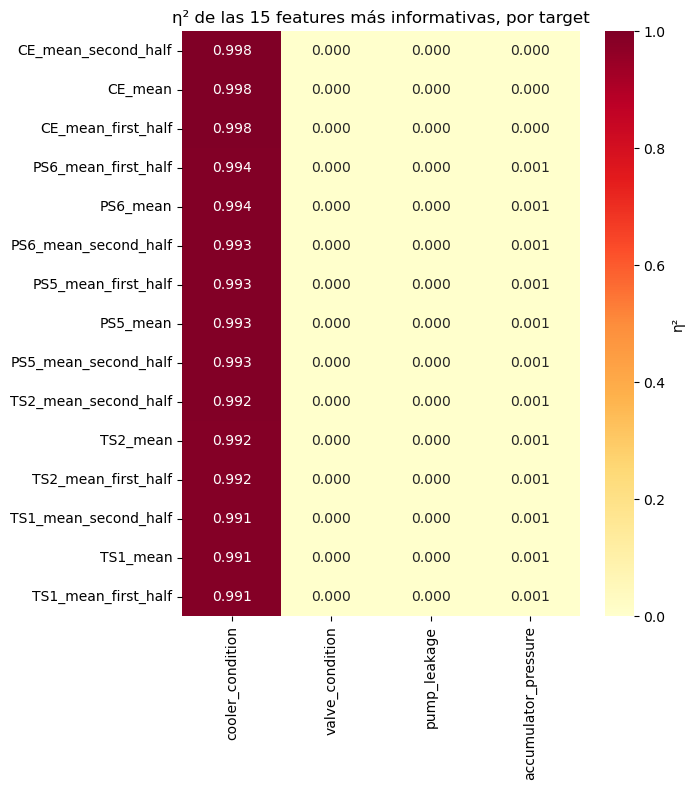

Top-15 features mostradas (orden de η² máximo descendente):
['CE_mean_second_half', 'CE_mean', 'CE_mean_first_half', 'PS6_mean_first_half', 'PS6_mean', 'PS6_mean_second_half', 'PS5_mean_first_half', 'PS5_mean', 'PS5_mean_second_half', 'TS2_mean_second_half', 'TS2_mean', 'TS2_mean_first_half', 'TS1_mean_second_half', 'TS1_mean', 'TS1_mean_first_half']


In [9]:
import matplotlib.pyplot as plt  # no importado en la Sección 0 de este notebook — no hacía falta hasta ahora
import seaborn as sns  # idem

FIGURES_DIR = Path.cwd().parent / "reports" / "figures"  # misma carpeta que usa 01_eda.ipynb
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Top-15 features por η² máximo entre los 4 targets, para un heatmap legible ──
top15_features = eta2_matrix.max(axis=1).sort_values(ascending=False).head(15).index.tolist()
eta2_top15 = eta2_matrix.loc[top15_features]

fig, ax = plt.subplots(figsize=(7, 8))
sns.heatmap(eta2_top15, annot=True, fmt=".3f", cmap="YlOrRd", vmin=0, vmax=1, ax=ax, cbar_kws={"label": "η²"})
ax.set_title("η² de las 15 features más informativas, por target")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_eta2_heatmap.png", bbox_inches="tight")
plt.show()

print("Top-15 features mostradas (orden de η² máximo descendente):")
print(top15_features)


### Interpretación

**El heatmap confirma la dominancia de `cooler_condition` de forma más contundente de lo anticipado — y por eso mismo revela una limitación real del criterio de selección "top-15 por η² máximo".** Las 15 filas mostradas tienen η²(cooler_condition) entre 0.9905 y 0.9984 (media=0.9936) — prácticamente 1.0 en las 15 — mientras que sus η² con los otros tres targets son, sin excepción, ≤0.0011 (medias: valve=0.0001, pump=0.0002, accumulator=0.0008). Visualmente, el heatmap es una columna casi enteramente roja (cooler) junto a tres columnas casi en blanco: exactamente el patrón que predijo la Decisión para `cooler_condition`, pero más extremo — no hay ninguna fila donde otro target compita ni de lejos.

**Lo que la Decisión anticipó mal: `PS3_peak_s` no aparece en absoluto.** Se esperaba que aportara una fila con η²(valve_condition) alto. En realidad, con η²(valve_condition)=0.9767, `PS3_peak_s` queda en el puesto **29 de 74** por η² máximo — muy por detrás de las 15 features dominadas por `cooler_condition` (todas ≥0.9905). El criterio "top-15 por η² máximo entre targets" no es neutral entre targets: favorece sistemáticamente a un target cuya señal es tanto fuerte **como** redundante entre muchas columnas (17 sensores × 4 estadísticas cada uno, casi todos con η²(cooler)>0.98) frente a un target cuya señal, aunque igual de fuerte en su mejor feature, está concentrada en una única columna. El resultado práctico: este heatmap concreto documenta perfectamente la historia de `cooler_condition`, pero no comunica nada sobre `valve_condition`, `pump_leakage` ni `accumulator_pressure` — para verlos haría falta un criterio de selección distinto (p. ej. top-N por cada target por separado, no un único ranking global), que queda fuera del alcance de esta sección pero es una corrección útil a tener en cuenta si se reutiliza este heatmap más adelante.

**Conclusión:** el heatmap es correcto y fiel a los datos, pero su valor diagnóstico está limitado al target que domina la selección. No es un error de cálculo — es una propiedad esperable de mezclar, en un mismo ranking, targets con una estructura de señal tan distinta (una redundante en 71 features vs. una concentrada en 1).